In [1]:
import os, sys
from pathlib import Path
sys.path.append('../src')
sys.path.append('../src/utils/')
from spiking_dataloader import WISDM_spiking_dataloader, WisdmDatasetParser
from inibitory_network.inibitory_network_h1_test import InibitoryLifNet
from lava.proc.io.sink import RingBuffer as SinkRingBuffer
from lava.proc.io.source import RingBuffer as SourceRingBuffer
from lava.proc.monitor.process import Monitor
from output_process import OutputProcess
from lava.proc.monitor.process import Monitor
import matplotlib.pyplot as plt
import numpy as np


In [2]:
import json
def deserialize_dict(json_str):
    def convert(obj):
        if isinstance(obj, dict) and 'data' in obj and 'dtype' in obj:
            return np.array(obj['data'], dtype=np.dtype(obj['dtype']))
        if isinstance(obj, list):
            return np.array(obj)
        return obj
    
    return json.loads(json_str, object_hook=lambda d: {k: convert(v) for k, v in d.items()})


In [3]:
#high score split [0, 2, 6, 8, 9, 14, 17]
#worst score split [0,1,2,5,6,7,12]
# balanced split [0, 1, 4, 8, 9, 10, 14]
dataset = WisdmDatasetParser('../data/data_watch_subset_0_40.npz', norm=None, class_sublset='custom', subset_list=[0, 2, 6, 8, 9, 14, 17])
num_samples = 1000
signal_steps = 40
clear_intervall = 4
time_steps = signal_steps + clear_intervall
val_idx = 277
#val_idx = 0
val_set = dataset.get_validation_set(subset=num_samples, shuffle=False)
val_set[0].shape
print(val_set[1])

(6,)
(6,)
ytrain shape (55404, 18)
yval shape (18468, 18)
ytest shape (18469, 18)
num classes train dataset: 7 occurrences of each class:[3127 2855 3102 3047 3150 2973 3213]
num classes eval dataset: 7 occurrences of each class:[1035  935 1122  996 1110 1007 1077]
num classes test dataset: 7 occurrences of each class:[1046  900 1046 1036 1076  982 1054]
[2 4 0 3 5 0 0 0 3 3 1 5 0 4 2 1 5 1 6 6 6 0 4 6 4 0 4 5 3 2 2 6 0 3 1 1 5 4 2 6 4 6 3 1 5 0 5 4 2 2 6 0 2 6 2 1 2 4 1 5 2 5 3 3 5 1 1 4 4 6 4 4 2 0 1 3 0 4 6 0 2 4 4 1 5 6 5 5 6 0 0 6 0 0 0 3 5 1 0 1 3 3 4 0 1 6 1 2 2 3 1 1 2 0 1 5 3 6 1 0 2 2 3 2 3 5 5 4 0 6 3 3 6 3 5 6 6 4 6 3 5 2 4 4 0 5 6 4 6 1 4 1 0 3 5 5 2 5 1 4 3 4 6 2 6 4 6 1 5 0 5 2 3 2 6 4 4 4 5 3 6 6 5 0 0 3 0 2 0 4 3 3 6 1 4 4 6 6 6 6 2 2 6 0 4 2 1 4 4 5 6 5 3 5 1 5 5 3 4 0 4 0 5 2 5 4 0 1 2 0 5 2 6 3 3 5 5 4 1 3 0 4 1 0 0 5 6 5 5 2 3 6 2 5 1 6 0 1 2 3 0 0 6 0 5 0 2 5 1 1 5 1 2 3 0 4 0 5 0 1 5 4 5 0 3 0 3 2 1 2 4 3 4 3 3 5 4 0 4 0 2 5 6 2 5 2 2 1 2 4 1 5 3 5 6 5 4 0 6 5 5 1

In [4]:
path = f"../data/lava_inhibitory_best.json"                                                                            
with open(path, 'r') as json_file:
    loaded_json_str = json_file.read()
converted_params = deserialize_dict(loaded_json_str)


In [5]:
signal_data = np.random.rand(6, time_steps) * 1
input_signal = val_set[0][val_idx,:,:]
#input_signal = np.hstack((val_set[0][val_idx,:,:], np.zeros((val_set[0][val_idx,:,:].shape[0], clear_intervall))))

input_data = SourceRingBuffer(data = input_signal)
#input_data = SourceRingBuffer(data = np.ones((6,time_steps))*2)
print(val_set[1][val_idx])

5


In [6]:
from lava.proc.lif.process import LIF
from lava.proc.dense.process import Dense, LearningDense 
from lava.utils.weightutils import SignMode   
from lif_mod import LIFEncoder
from dense_mod import DenseEncoder

name = "linear1"
linear1_w = np.array(converted_params[name]["weights"])

linear1 = DenseEncoder(weights=linear1_w,
                       num_message_bits=32,
                       name="linear1")

name = "leaky1"

leaky1 = LIFEncoder(shape=(linear1_w.shape[0],),
                    u = np.zeros(linear1_w.shape[0]),
                    v = np.zeros(linear1_w.shape[0]),
                    du = converted_params[name]["du"],
                    dv = converted_params[name]["dv"],
                    vth=converted_params[name]["vth"],
                    log_config=0,
                    name= "leaky1"
                )
linear1.a_out.connect(leaky1.a_in)

name = "linear2"
linear2_w = np.array(converted_params[name]["weights"])

linear2 = Dense(**converted_params[name],
                sign_mode=SignMode.MIXED,
                name=name)

linear2.s_in.connect_from(leaky1.s_out)

name = "leaky2"
leaky2 = LIF(shape=(linear2_w.shape[0],),
                    **converted_params[name],
                    name= name
                )
#sum.a_out.connect(leaky2.a_in)
linear2.a_out.connect(leaky2.a_in)
#leaky2.a_in.connect_from(linear2.a_out)
name = "recurrent_in"
recurrent_in_weights = np.array(converted_params[name]["weights"])

recurrent_in = Dense(**converted_params[name],
                     name=name)

leaky2.s_out.connect(recurrent_in.s_in)

name = "inibitory_leaky"
ahpc = LIF(shape=(recurrent_in_weights.shape[0],),
                    **converted_params[name],
                    log_config=0,
                    name= name
                )

recurrent_in.a_out.connect(ahpc.a_in)
name = "recurrent_out"
recurrent_out = Dense(**converted_params[name],
                       name=name)
recurrent_out.s_in.connect_from(ahpc.s_out)
recurrent_out.a_out.connect(leaky2.a_in)

name = "linear3"
linear3_w = np.array(converted_params[name]["weights"])
linear3 = Dense(**converted_params[name],
                        name=name)

linear3.s_in.connect_from(leaky2.s_out)
name = "leaky3"
leaky3 = LIF(shape=(linear3_w.shape[0],),
                    **converted_params[name],
                    log_config=0,
                    name= name
                )
leaky3.a_in.connect_from(linear3.a_out)

monitor_leaky1_u = Monitor()
monitor_leaky1_u.probe(target=leaky1.v, num_steps=time_steps)

monitor_leaky2_u = Monitor()
monitor_leaky2_u.probe(target=leaky2.v, num_steps=time_steps)

monitor_leaky3_u = Monitor()
monitor_leaky3_u.probe(target=leaky3.v, num_steps=time_steps)

monitor_recurrent_u = Monitor()
monitor_recurrent_u.probe(target=ahpc.v, num_steps=time_steps)

in_sink = SinkRingBuffer(shape=(linear1_w.shape[0],), buffer=time_steps)
b_sink = SinkRingBuffer(shape=(linear2_w.shape[0],), buffer=time_steps)
f_sink = SinkRingBuffer(shape=(linear2_w.shape[0],),buffer=time_steps)
out_sink = SinkRingBuffer(shape=(7,),buffer=time_steps)

input_data.s_out.connect(linear1.s_in)
leaky1.s_out.connect(in_sink.a_in)
leaky3.s_out.connect(out_sink.a_in)
ahpc.s_out.connect(b_sink.a_in)
leaky2.s_out.connect(f_sink.a_in)

In [7]:

from lava.magma.core.run_conditions import RunSteps
from lava.magma.core.run_configs import Loihi1SimCfg, Loihi2SimCfg
from lava.utils.float2fixed import Float2FixedConverter
import numpy as np
from tqdm import tqdm


out_sink.run(condition=RunSteps(num_steps=time_steps),
                run_cfg=Loihi1SimCfg(select_sub_proc_model=True,
                select_tag='fixed_pt'))

# converter = Float2FixedConverter()
# converter.set_run_cfg(fixed_pt_run_cfg=Loihi1SimCfg(select_tag='fixed_pt'),
#                       floating_pt_run_cfg=Loihi1SimCfg())
# converter.convert([net], num_steps=time_steps)
# converter.scaled_params
# print(converter.scaled_params)
leaky1_u = monitor_leaky1_u.get_data()
_ , leaky1_u = next(iter(leaky1_u.items()))
_ , leaky1_u = next(iter(leaky1_u.items()))
leaky2_u = monitor_leaky2_u.get_data()
_ , leaky2_u = next(iter(leaky2_u.items()))
_ , leaky2_u = next(iter(leaky2_u.items()))
leaky3_u = monitor_leaky3_u.get_data()
_ , leaky3_u = next(iter(leaky3_u.items()))
_ , leaky3_u = next(iter(leaky3_u.items()))
recurrent_u = monitor_recurrent_u.get_data()
_ , recurrent_u = next(iter(recurrent_u.items()))
_ , recurrent_u = next(iter(recurrent_u.items()))

out_data = np.array(out_sink.data.get())
in_data = np.array(in_sink.data.get())
b_data = np.array(b_sink.data.get())
f_data = np.array(f_sink.data.get())

print(leaky1_u.shape)
print(leaky2_u.shape)

out_sink.stop()




(44, 140)
(44, 550)


In [8]:
def create_raster_plot(data, name=None, figsize=(16,10), label_fontsize=14, tick_fontsize=16):
    plt.clf()
    channels, timesteps = data.shape
    if figsize is None:
        x_size = timesteps / 2
        y_size = channels / 10 if channels > 100 else channels 
        figsize = (x_size, y_size)
    else:
        figsize = figsize

    plt.figure(figsize=figsize)
    print(data.shape)
    for channel in range(data.shape[0]):
        spike_times = np.where(data[channel])[0]
        plt.scatter(spike_times, [channel + 1] * len(spike_times), s=10, color='blue')

    # Place an invisible dot above the highest channel
    plt.scatter([0], [channels + 1], s=10, color='none', edgecolor='none')

    if name:
        plt.title(f"{name} Raster Plot", fontsize=label_fontsize)
    else:
        plt.title('Raster Plot', fontsize=label_fontsize)

    # Remove the y-ticks if there are more than 10 channels
    if channels > 10:
        plt.yticks([])  # Remove y-ticks
    else:
        plt.yticks(np.arange(1, data.shape[0] + 1), [f'N {i}' for i in range(data.shape[0])], fontsize=tick_fontsize)

    plt.xlabel('Timesteps', fontsize=label_fontsize)
    plt.ylabel('Channels', fontsize=label_fontsize)
    plt.ylim(0, data.shape[0] + 1)  # Extend y-axis limit to include the invisible dot
    plt.xlim(0, data.shape[1])
    plt.xticks(ticks=np.arange(data.shape[1]), labels=np.arange(data.shape[1]), fontsize=tick_fontsize)
    plt.grid(axis='x', color='black', linestyle='--', linewidth=0.2)
    plt.show()

def plot_signals(matrix, name=None, figsize=(15,10),  tick_fontsize=14, label_fontsize=16):
    """
    Plots the signal for each channel in the provided matrix.
    
    Parameters:
    matrix (np.ndarray): A 2D array where the first dimension represents channels
                         and the second dimension represents timesteps.
    """
    channels, timesteps = matrix.shape

    if figsize is None:
        x_size = timesteps / 2
        y_size = channels / 10 if channels > 100 else channels 
        figsize = (x_size, y_size)
    else:
        figsize = figsize

    plt.figure(figsize=figsize)
    for i in range(channels):
        plt.plot(matrix[i], label=f'Channel {i+1}')
    
    if name:
        plt.title(f"{name} Signal Plot")
    else:
        plt.title('Signal Plot')

    plt.xlabel('Timestep',  fontsize=label_fontsize)
    plt.ylabel('Signal Value', fontsize=label_fontsize)
    plt.xlim(0, matrix.shape[1])
    plt.xticks(ticks=np.arange(matrix.shape[1]), labels=np.arange(matrix.shape[1]))
    plt.grid(axis='x', color='black', linestyle='--', linewidth=0.2)
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    #plt.legend(ncol=12, loc='upper center', bbox_to_anchor=(0.5, -0.05), facecolor='white', framealpha=1)
    plt.show()


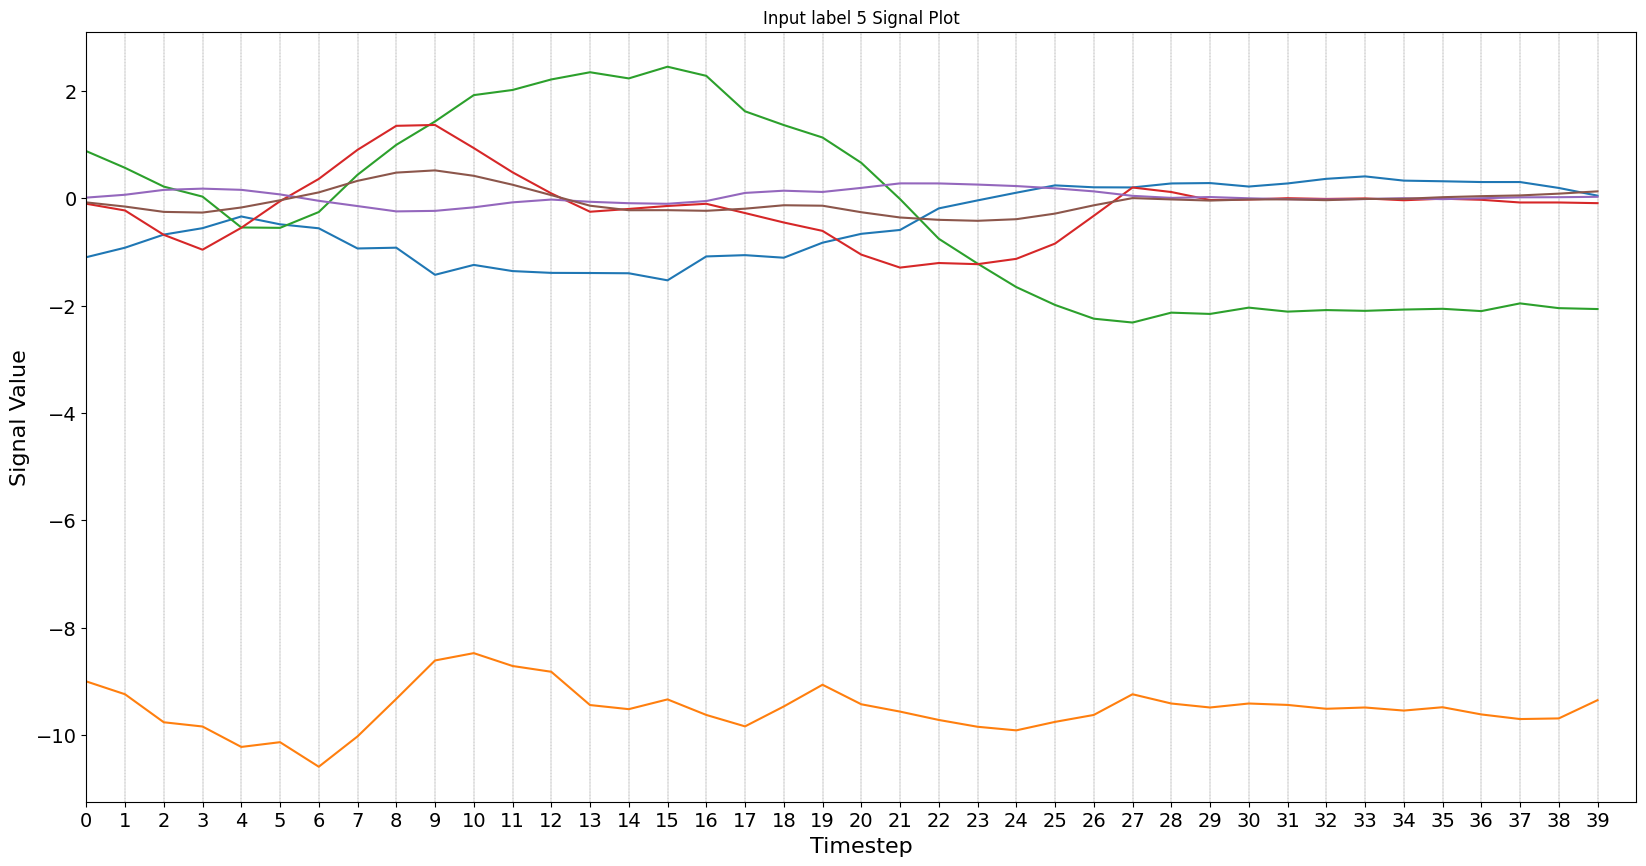

In [9]:
plot_signals(input_signal, figsize=(20,10), name=f'Input label {val_set[1][val_idx]}')

(140, 44)


<Figure size 640x480 with 0 Axes>

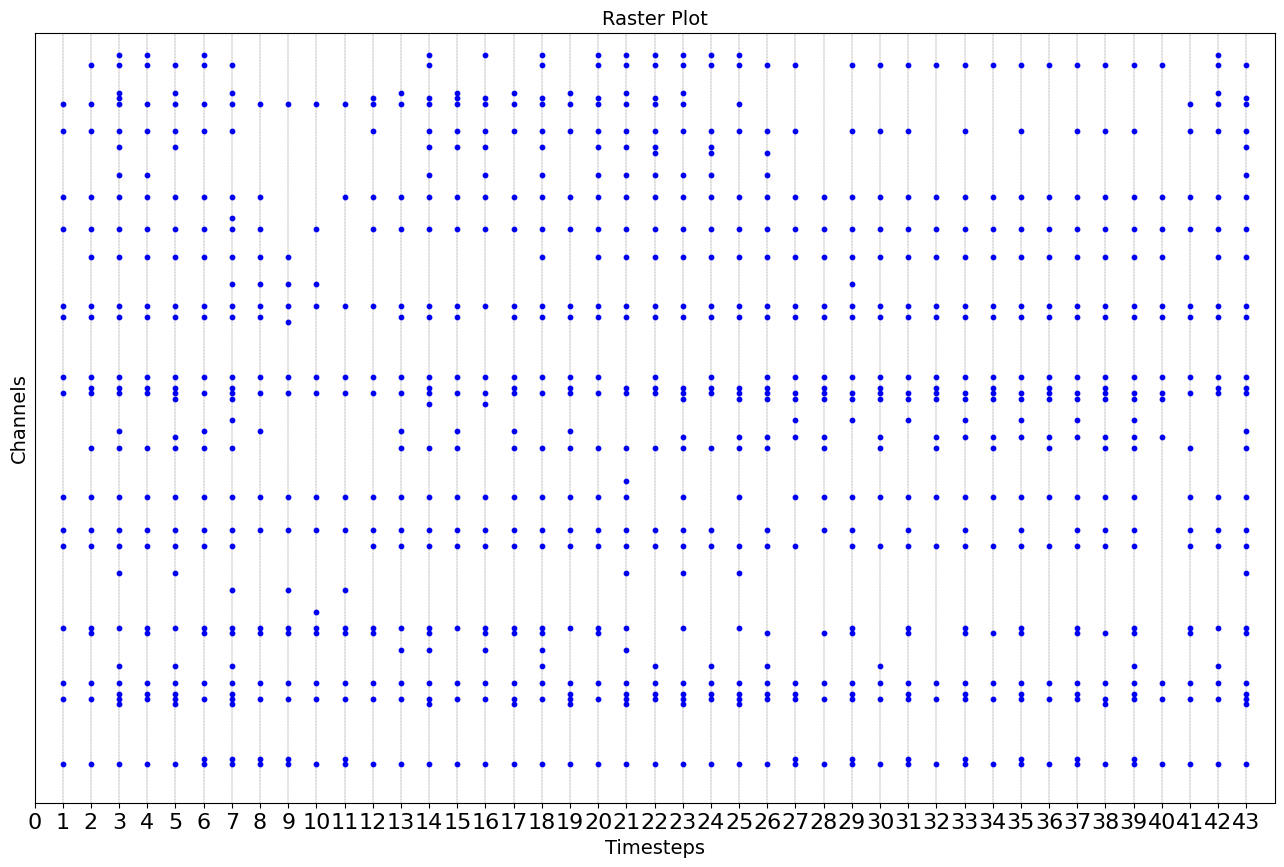

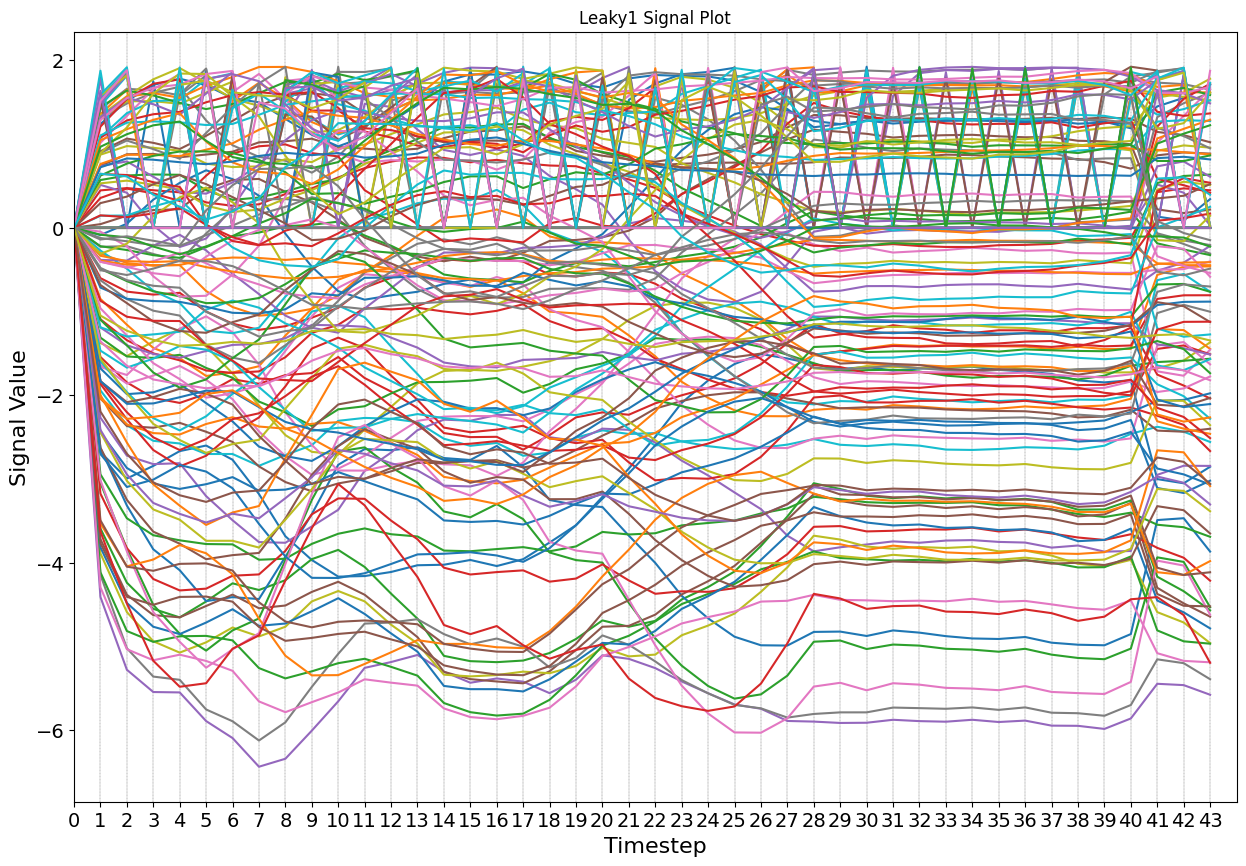

In [10]:
create_raster_plot(in_data)
plot_signals(leaky1_u.T, name='Leaky1')


(550, 44)


<Figure size 640x480 with 0 Axes>

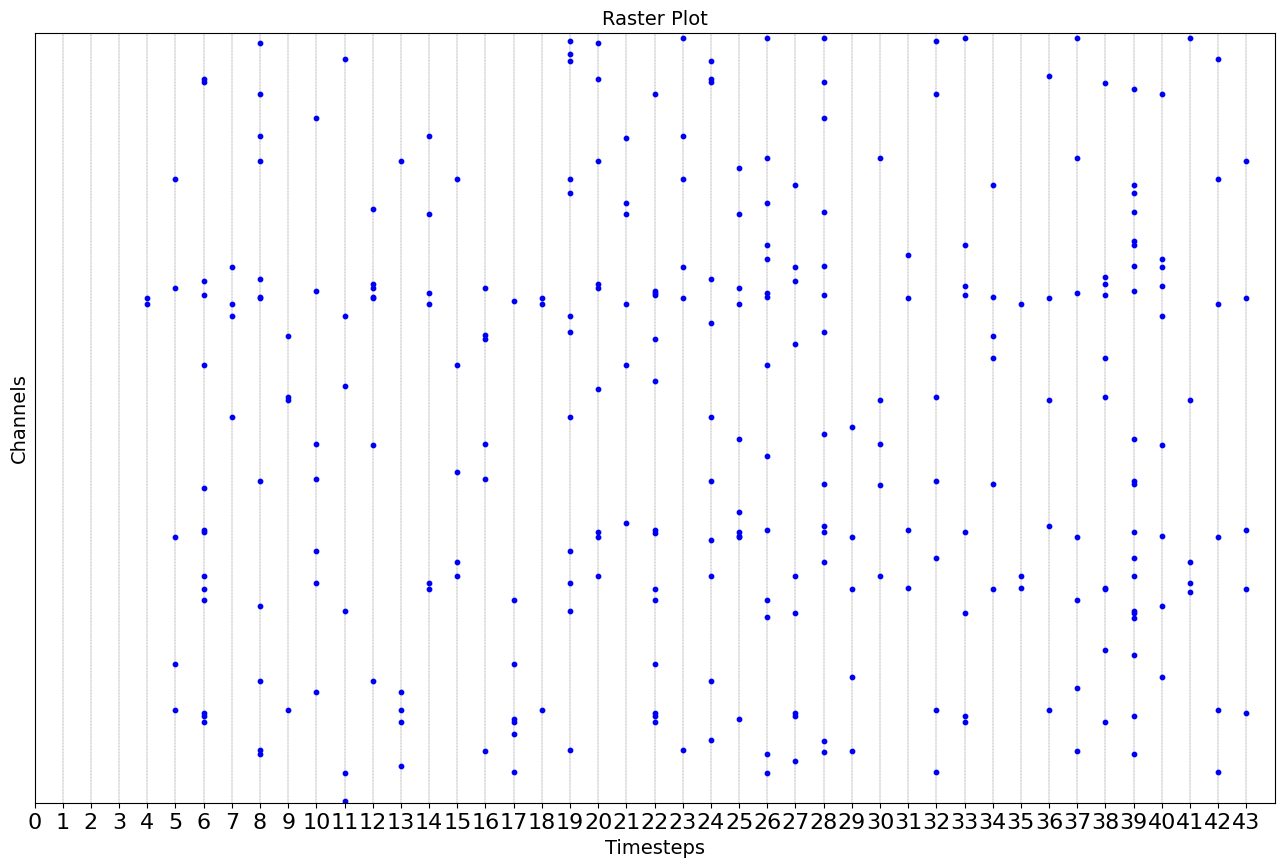

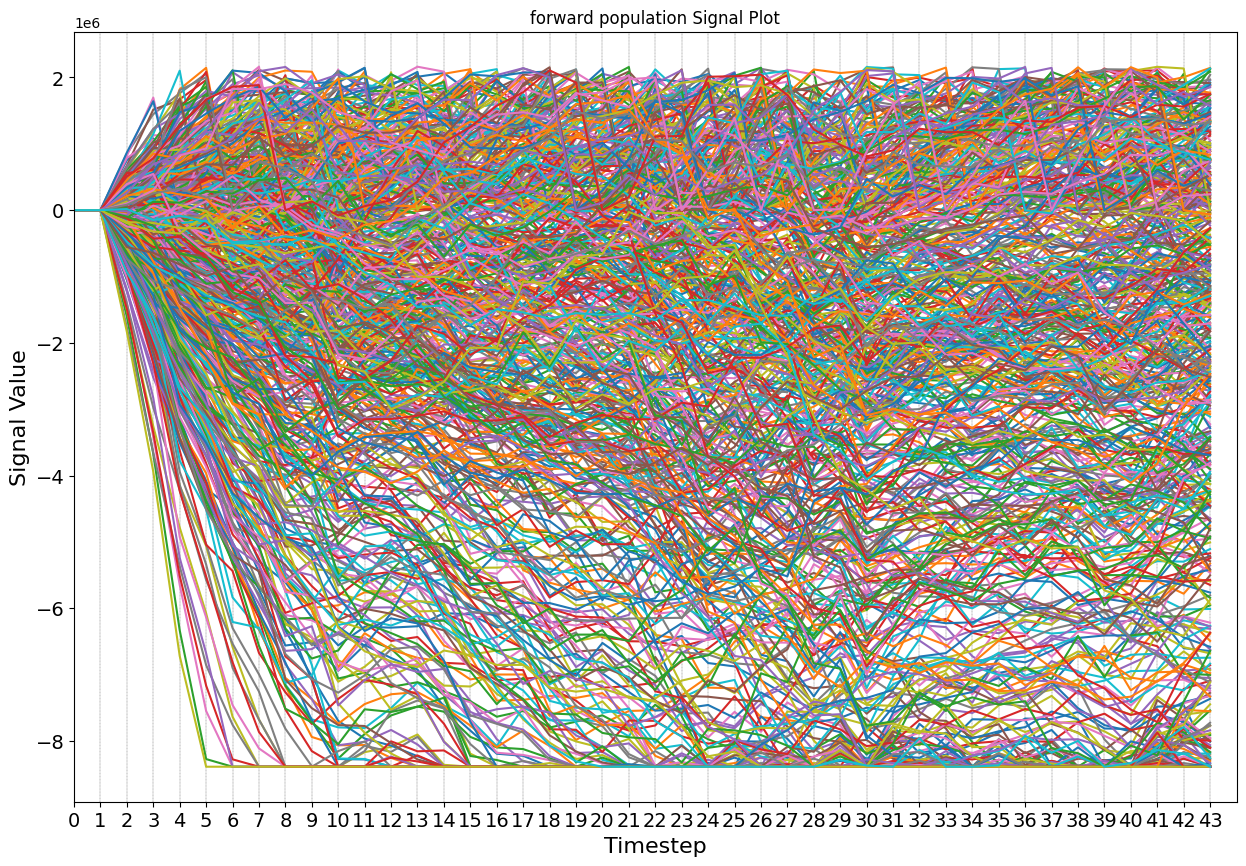

In [11]:
create_raster_plot(f_data)
plot_signals(leaky2_u.T, name='forward population')

(550, 44)


<Figure size 640x480 with 0 Axes>

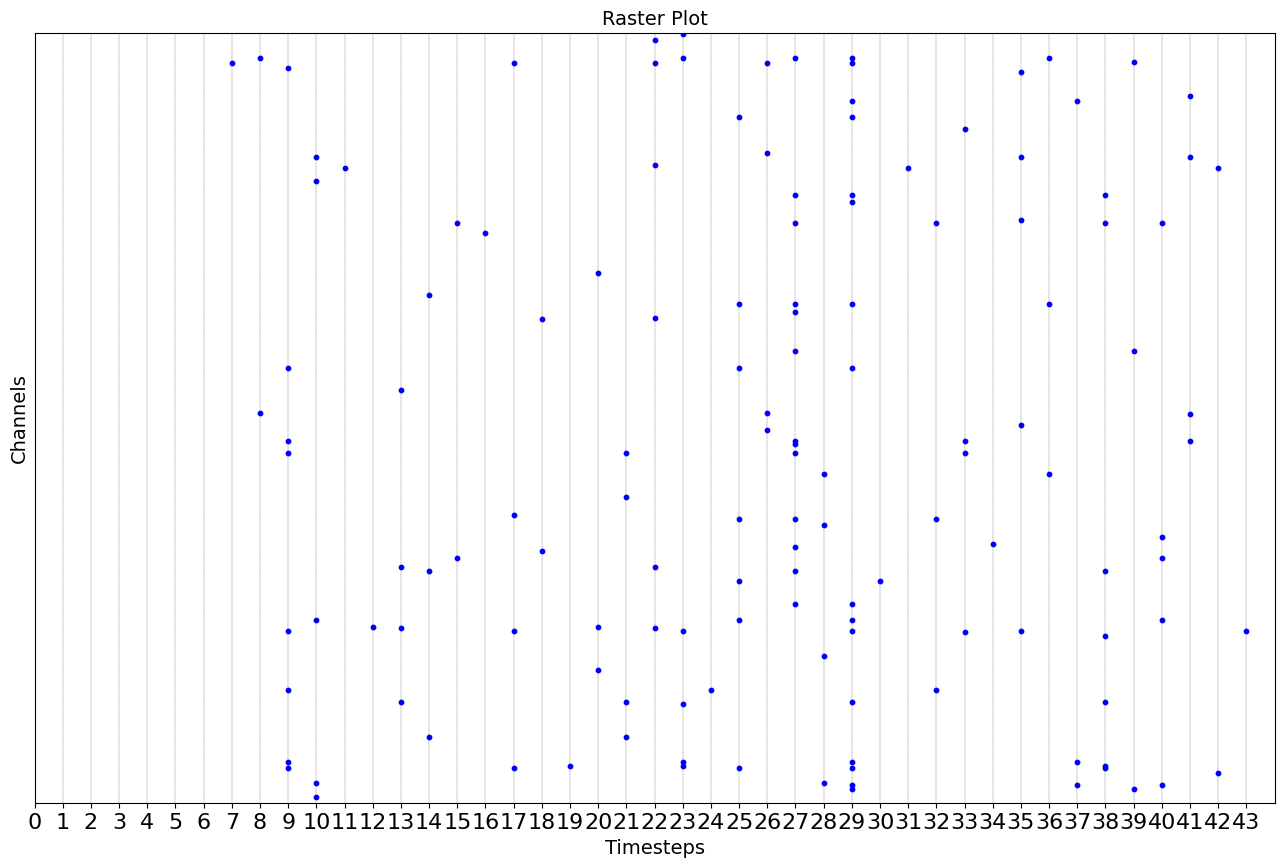

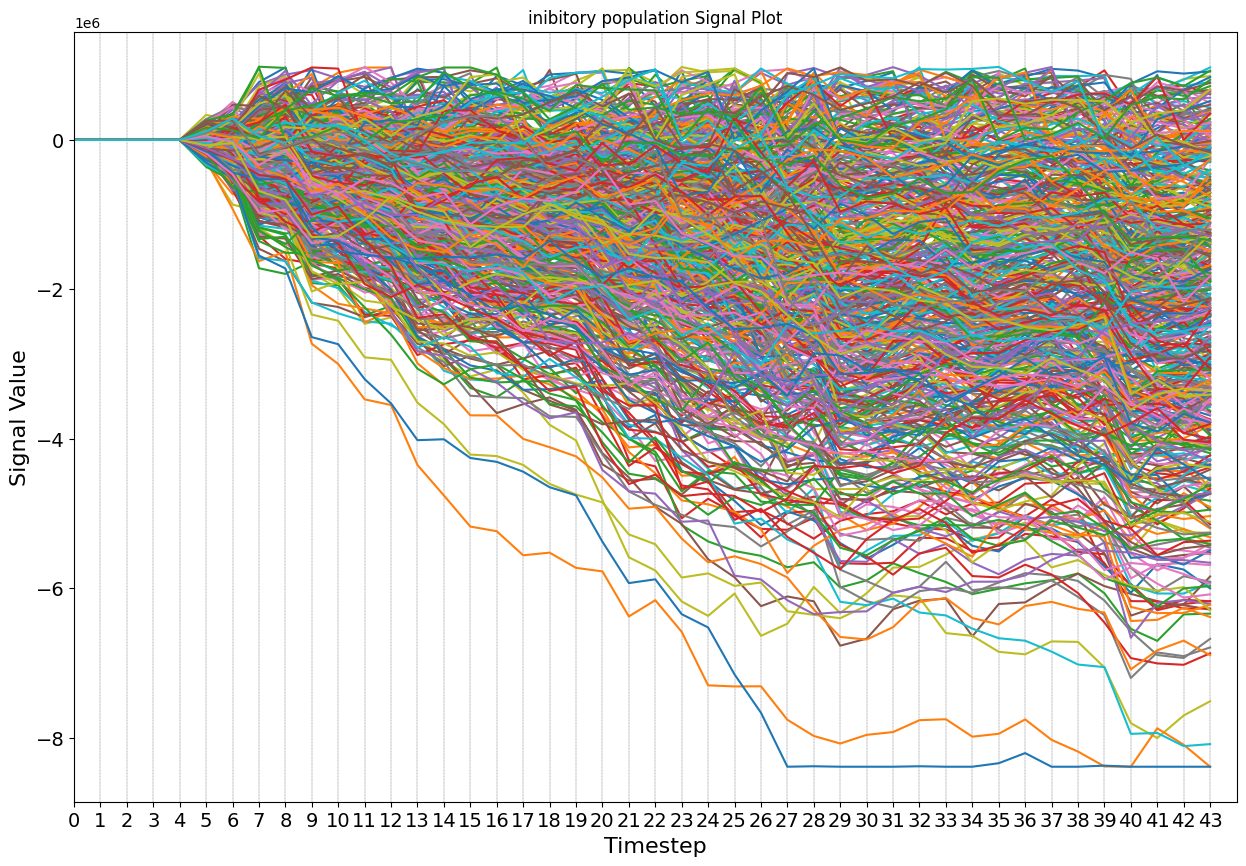

In [12]:
create_raster_plot(b_data)
plot_signals(recurrent_u.T, name='inibitory population')

correct label: 5
predicted label: 4
(7, 44)


<Figure size 640x480 with 0 Axes>

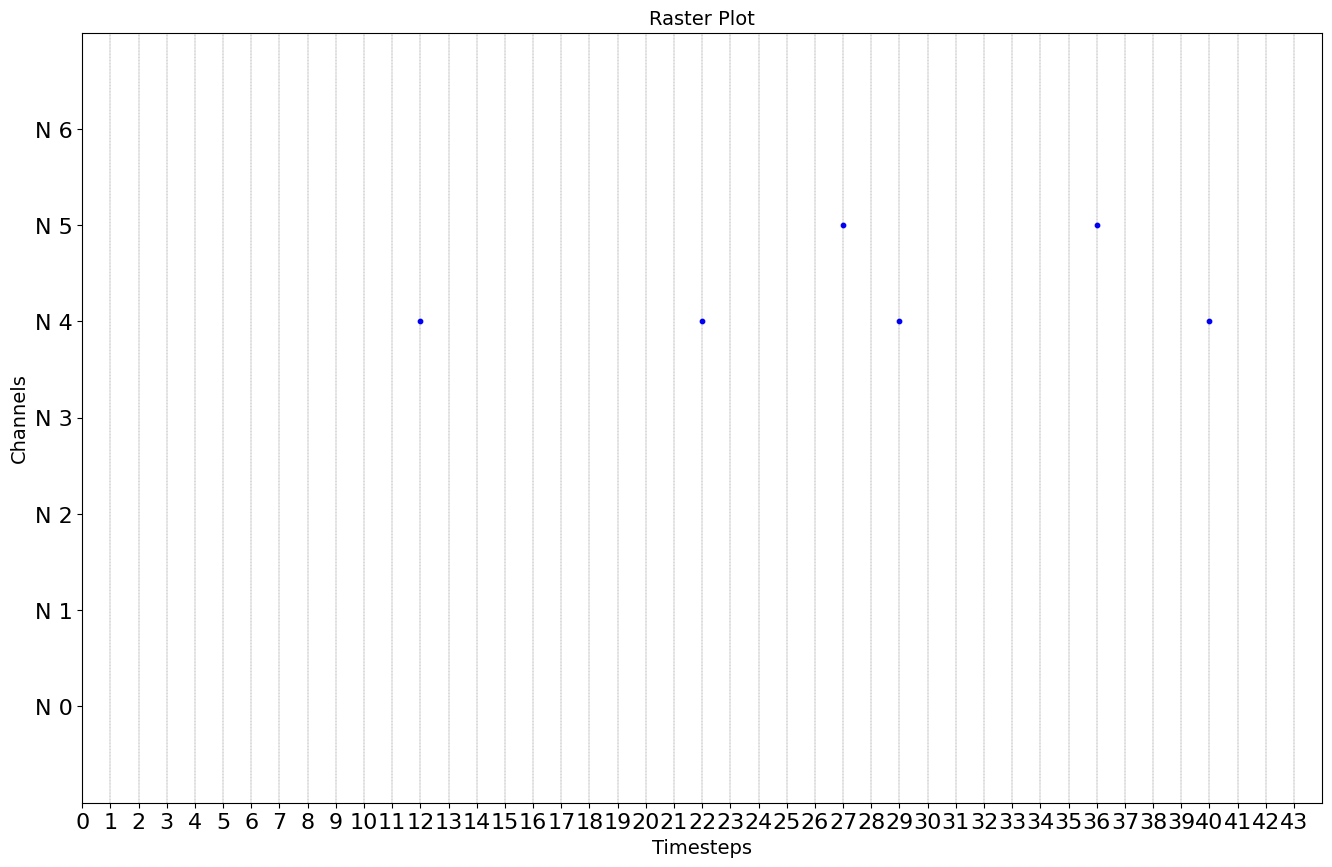

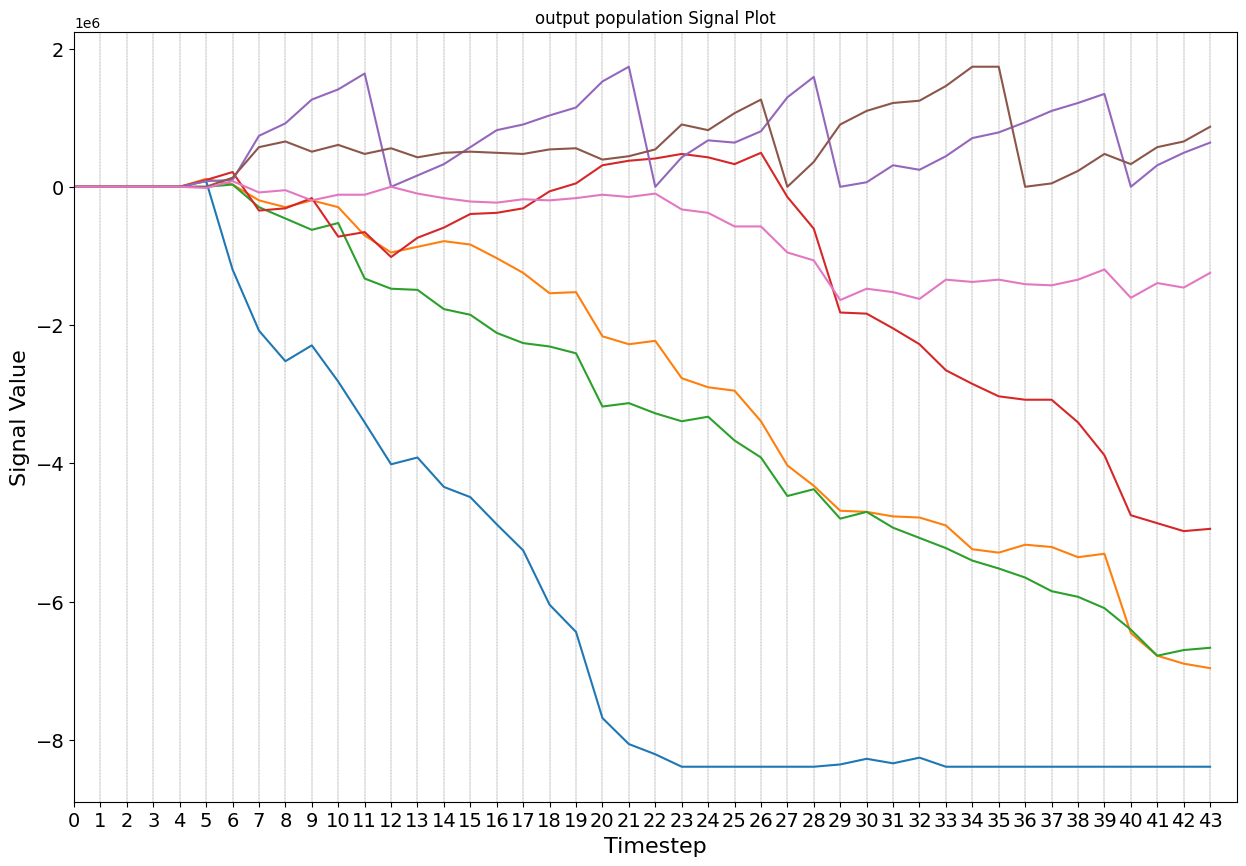

In [13]:
print(f"correct label: {val_set[1][val_idx]}")
print(f"predicted label: {np.argmax(np.sum(out_data, axis=-1))}")
create_raster_plot(out_data)
plot_signals(leaky3_u.T, name='output population')


In [14]:
float_v = np.array([0.8]).astype(np.float32)
print(float_v)
int_v = float_v.astype(np.int32)
print(int_v)

[0.8]
[0]


In [15]:
float_v = np.array([1.8]).astype(np.float32)
print(float_v)
int_v = float_v.astype(np.int32)
print(int_v)

[1.8]
[1]
